Sales Forecasting Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.datasets import get_rdataset

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
dataset = get_rdataset("AirPassengers").data

data = dataset.copy()
data['time'] = pd.date_range(start='1949-01', periods=len(data), freq='M')
data.set_index('time', inplace=True)

data.rename(columns={'value': 'sales'}, inplace=True)
data.head()

C:\Users\insp 5430\AppData\Local\Temp\ipykernel_1644\3565050418.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data['time'] = pd.date_range(start='1949-01', periods=len(data), freq='M')


,sales
time,
1949-01-31,112
1949-02-28,118
1949-03-31,132
1949-04-30,129
1949-05-31,121


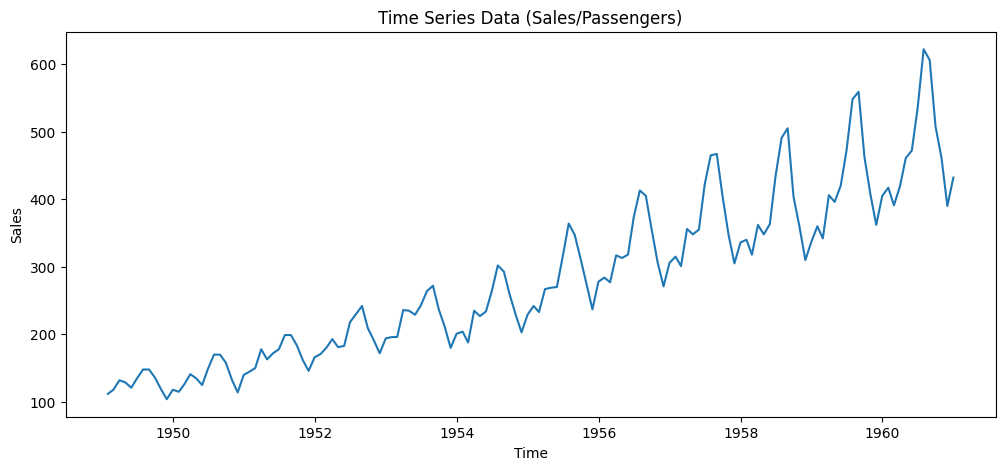

In [4]:
plt.figure(figsize=(12,5))
plt.plot(data['sales'])
plt.title("Time Series Data (Sales/Passengers)")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()

In [5]:
train_size = int(len(data) * 0.8)
train = data[:train_size]
test = data[train_size:]

ARIMA Model

In [6]:
arima_model = ARIMA(train['sales'], order=(2,1,2))
arima_fit = arima_model.fit()

C:\Users\insp 5430\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\insp 5430\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\insp 5430\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [7]:
arima_forecast = arima_fit.forecast(steps=len(test))

In [8]:
arima_rmse = np.sqrt(mean_squared_error(test['sales'], arima_forecast))
print("ARIMA RMSE:", arima_rmse)

ARIMA RMSE: 82.51301130091208


LSTM Model

In [9]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [10]:
def create_dataset(data, time_step=12):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 12

X, y = create_dataset(scaled_data, time_step)

In [11]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [12]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [13]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=10, batch_size=16)

C:\Users\insp 5430\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1012
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0183
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0141
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0105
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0135 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0084 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0077
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0070
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0067
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0078


In [14]:
lstm_pred = model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step


In [15]:
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
print("LSTM RMSE:", lstm_rmse)

LSTM RMSE: 74.57360754758888


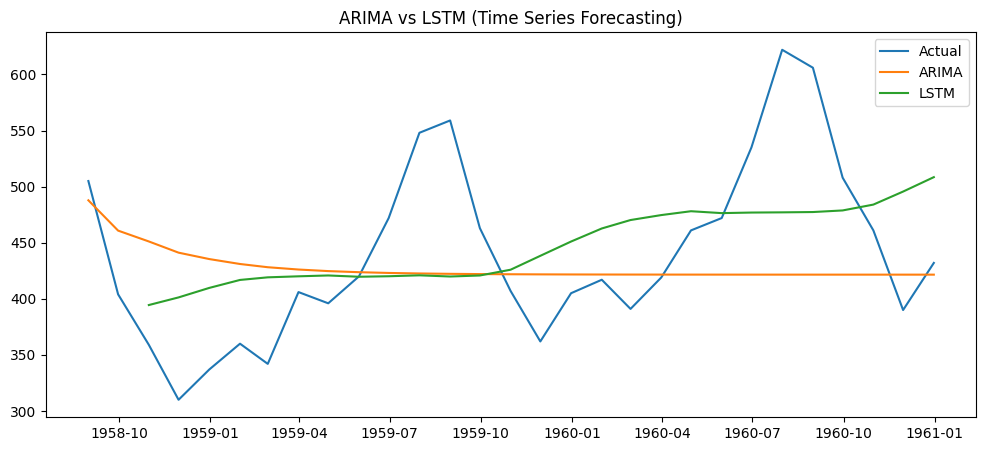

In [16]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test['sales'], label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA')
plt.plot(test.index[-len(lstm_pred):], lstm_pred, label='LSTM')
plt.legend()
plt.title("ARIMA vs LSTM (Time Series Forecasting)")
plt.show()